# JMLR Thematic Alignment Analysis

This notebook quantitatively assesses whether papers published in the **Journal of Machine Learning Research (JMLR)** align with its stated Aims & Scope, using semantic embeddings and cosine similarity.

**Pipeline:**
1. Fetch paper metadata from arXiv
2. Preprocess abstracts
3. Generate TF-IDF and SBERT embeddings
4. Compute alignment scores
5. Detect outliers
6. Topic modelling with BERTopic
7. UMAP dimensionality reduction
8. Visualisation

## 0. Imports & Setup

In [2]:
pip install arxiv bertopic sentence-transformers umap-learn

  Using cached arxiv-4.0.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached bertopic-0.17.4-py3-none-any.whl.metadata (24 kB)
  Using cached sentence_transformers-5.5.1-py3-none-any.whl.metadata (18 kB)
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Using cached lxml-6.1.1-cp313-cp313-win_amd64.whl.metadata (3.6 kB)
  Using cached hdbscan-0.8.43-cp313-cp313-win_amd64.whl.metadata (15 kB)
  Using cached transformers-5.9.0-py3-none-any.whl.metadata (33 kB)
  Using cached huggingface_hub-1.16.1-py3-none-any.whl.metadata (14 kB)
  Using cached torch-2.12.0-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached regex-2026.5.9-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached pynnd

In [3]:
import re
import time
import logging

import arxiv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from umap import UMAP

sns.set_theme(style="whitegrid", font_scale=1.1)
logging.basicConfig(level=logging.INFO)

SBERT_COL  = "sbert_alignment_score"
TFIDF_COL  = "tfidf_alignment_score"
MAX_PAPERS = 500

## 1. Data Collection — fetch papers from arXiv

In [4]:
client = arxiv.Client()

search = arxiv.Search(
    query='jo:"Journal of Machine Learning Research"',
    max_results=MAX_PAPERS,
    sort_by=arxiv.SortCriterion.SubmittedDate,
    sort_order=arxiv.SortOrder.Descending,
)

records = []
for i, result in enumerate(client.results(search)):
    records.append({
        "title":    result.title,
        "abstract": result.summary,
        "authors":  ", ".join(a.name for a in result.authors),
        "year":     result.published.year,
        "doi":      result.doi or "",
        "arxiv_id": result.entry_id,
    })
    if (i + 1) % 50 == 0:
        print(f"  Fetched {i + 1} records...")
        time.sleep(1.0)

print(f"\nTotal records fetched: {len(records)}")

INFO:arxiv:Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=jo%3A%22Journal+of+Machine+Learning+Research%22&id_list=&sortBy=submittedDate&sortOrder=descending&start=0&max_results=100
INFO:arxiv:Got first page: 100 of 925 total results


  Fetched 50 records...
  Fetched 100 records...


INFO:arxiv:Sleeping: 0.863332 seconds
INFO:arxiv:Requesting page (first: False, try: 0): https://export.arxiv.org/api/query?search_query=jo%3A%22Journal+of+Machine+Learning+Research%22&id_list=&sortBy=submittedDate&sortOrder=descending&start=100&max_results=100


  Fetched 150 records...
  Fetched 200 records...


INFO:arxiv:Sleeping: 0.947512 seconds
INFO:arxiv:Requesting page (first: False, try: 0): https://export.arxiv.org/api/query?search_query=jo%3A%22Journal+of+Machine+Learning+Research%22&id_list=&sortBy=submittedDate&sortOrder=descending&start=200&max_results=100


  Fetched 250 records...
  Fetched 300 records...


INFO:arxiv:Sleeping: 0.926495 seconds
INFO:arxiv:Requesting page (first: False, try: 0): https://export.arxiv.org/api/query?search_query=jo%3A%22Journal+of+Machine+Learning+Research%22&id_list=&sortBy=submittedDate&sortOrder=descending&start=300&max_results=100


  Fetched 350 records...
  Fetched 400 records...


INFO:arxiv:Sleeping: 0.899923 seconds
INFO:arxiv:Requesting page (first: False, try: 0): https://export.arxiv.org/api/query?search_query=jo%3A%22Journal+of+Machine+Learning+Research%22&id_list=&sortBy=submittedDate&sortOrder=descending&start=400&max_results=100


  Fetched 450 records...
  Fetched 500 records...

Total records fetched: 500


## 2. Preprocessing — clean abstracts

In [5]:
def clean_text(text):
    """Lowercase, collapse whitespace, strip non-alphanumeric characters."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z0-9\s\.\,\-]', '', text)
    return text.strip()


df = pd.DataFrame(records)
df = df.dropna(subset=["abstract"])
df = df[df["abstract"].str.strip() != ""]
df["clean_abstract"] = df["abstract"].apply(clean_text)

# Drop any papers where the query term 'jo' leaked into the abstract
df = df[~df["clean_abstract"].str.contains(r'\bjo\b', regex=True)]
df = df.reset_index(drop=True)

print(f"Papers after cleaning: {len(df)}")
print(f"Year range: {df['year'].min()}–{df['year'].max()}")
df.head(3)

Papers after cleaning: 467
Year range: 2019–2026


,title,abstract,authors,year,doi,arxiv_id,clean_abstract
0,Bayesian policy gradient and actor-critic algo...,Policy gradient methods are reinforcement lear...,"Mohammad Ghavamzadeh, Yaakov Engel, Michal Valko",2026,,http://arxiv.org/abs/2604.27563v1,policy gradient methods are reinforcement lear...
1,Spectral bandits,Smooth functions on graphs have wide applicati...,"Tomáš Kocák, Rémi Munos, Branislav Kveton, Shi...",2026,,http://arxiv.org/abs/2604.25272v1,smooth functions on graphs have wide applicati...
2,Blind-Spot Mass: A Good-Turing Framework for Q...,Blind-spot mass is a Good-Turing framework for...,"Biplab Pal, Santanu Bhattacharya, Madanjit Singh",2026,,http://arxiv.org/abs/2604.05057v1,blind-spot mass is a good-turing framework for...


In [33]:
df['year'].value_counts().sort_index()

year
2019     34
2020     94
2021    113
2022     77
2023     80
2024     45
2025     20
2026      4
Name: count, dtype: int64

## 3. Aims & Scope — reference text

In [6]:
AIMS_AND_SCOPE = """
The Journal of Machine Learning Research (JMLR) provides an international 
forum for the electronic and paper publication of high-quality scholarly 
articles in all areas of machine learning. All published papers are freely 
available online. JMLR has a commitment to rigorous yet rapid reviewing.

JMLR seeks previously unpublished papers on machine learning that contain:
- Novel principled machine learning algorithms and their applications
- Analysis of algorithms and the computational complexity of learning
- Studies on the statistical aspects of learning, including consistency and rates of convergence
- Papers that bridge machine learning and statistics, computational complexity, or other fields
- Experimental and theoretical work on neural networks, kernel methods, Bayesian approaches
- Reinforcement learning, unsupervised learning, supervised learning
- Representation learning, deep learning, optimization for machine learning
- Fairness, robustness, and interpretability in machine learning systems
- Applications of machine learning to real-world problems
"""

print(AIMS_AND_SCOPE)


The Journal of Machine Learning Research (JMLR) provides an international 
forum for the electronic and paper publication of high-quality scholarly 
articles in all areas of machine learning. All published papers are freely 
available online. JMLR has a commitment to rigorous yet rapid reviewing.

JMLR seeks previously unpublished papers on machine learning that contain:
- Novel principled machine learning algorithms and their applications
- Analysis of algorithms and the computational complexity of learning
- Studies on the statistical aspects of learning, including consistency and rates of convergence
- Papers that bridge machine learning and statistics, computational complexity, or other fields
- Experimental and theoretical work on neural networks, kernel methods, Bayesian approaches
- Reinforcement learning, unsupervised learning, supervised learning
- Representation learning, deep learning, optimization for machine learning
- Fairness, robustness, and interpretability in machine

## 4. Embeddings

### 4a. TF-IDF (baseline)

In [7]:
abstracts = df["clean_abstract"].fillna("").tolist()
all_texts  = [AIMS_AND_SCOPE] + abstracts

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
)
tfidf_matrix   = tfidf_vectorizer.fit_transform(all_texts).toarray()
tfidf_scope    = tfidf_matrix[0]          # shape (5000,)
tfidf_abstracts = tfidf_matrix[1:]        # shape (n_papers, 5000)

print(f"TF-IDF abstracts shape: {tfidf_abstracts.shape}")

TF-IDF abstracts shape: (467, 5000)


### 4b. SBERT (semantic)

In [8]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

sbert_scope     = sbert_model.encode([AIMS_AND_SCOPE], show_progress_bar=False, convert_to_numpy=True)[0]
sbert_abstracts = sbert_model.encode(abstracts, show_progress_bar=True, batch_size=32, convert_to_numpy=True)

print(f"SBERT scope shape:     {sbert_scope.shape}")
print(f"SBERT abstracts shape: {sbert_abstracts.shape}")

INFO:sentence_transformers.base.model:No device provided, using cpu
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Re

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

SBERT scope shape:     (384,)
SBERT abstracts shape: (467, 384)


## 5. Alignment Scores — cosine similarity

In [9]:
def compute_alignment_scores(scope_vec, abstract_matrix):
    """Cosine similarity between a scope vector and every abstract."""
    scores = cosine_similarity(scope_vec.reshape(1, -1), abstract_matrix)
    return scores.flatten()


tfidf_scores = compute_alignment_scores(tfidf_scope, tfidf_abstracts)
sbert_scores = compute_alignment_scores(sbert_scope, sbert_abstracts)

df[TFIDF_COL] = tfidf_scores
df[SBERT_COL] = sbert_scores

print(f"TF-IDF — mean: {tfidf_scores.mean():.4f}  std: {tfidf_scores.std():.4f}")
print(f"SBERT  — mean: {sbert_scores.mean():.4f}  std: {sbert_scores.std():.4f}")
df[["title", "year", TFIDF_COL, SBERT_COL]].head()

TF-IDF — mean: 0.0428  std: 0.0368
SBERT  — mean: 0.3269  std: 0.0909


,title,year,tfidf_alignment_score,sbert_alignment_score
0,Bayesian policy gradient and actor-critic algo...,2026,0.065899,0.425276
1,Spectral bandits,2026,0.080120,0.365451
2,Blind-Spot Mass: A Good-Turing Framework for Q...,2026,0.030839,0.333722
3,The Causal Uncertainty Principle: Manifold Tea...,2026,0.007468,0.165240
4,DeepCAVE: A Visualization and Analysis Tool fo...,2025,0.080364,0.433507


## 6. Outlier Detection (±2σ)

In [10]:
def detect_outliers(df, score_col=SBERT_COL, threshold=2.0):
    """Flag papers more than `threshold` std devs from the mean."""
    mean = df[score_col].mean()
    std  = df[score_col].std()
    df = df.copy()
    df["score_mean"] = mean
    df["score_std"]  = std
    df["outlier_type"] = None
    df.loc[df[score_col] > mean + threshold * std, "outlier_type"] = "high"
    df.loc[df[score_col] < mean - threshold * std, "outlier_type"] = "low"
    return df


df = detect_outliers(df, threshold=2.0)

mean  = df["score_mean"].iloc[0]
std   = df["score_std"].iloc[0]
n_high = (df["outlier_type"] == "high").sum()
n_low  = (df["outlier_type"] == "low").sum()

print(f"Corpus mean : {mean:.4f}")
print(f"Corpus std  : {std:.4f}")
print(f"Upper bound (+2σ): {mean + 2*std:.4f}  →  {n_high} high outliers")
print(f"Lower bound (−2σ): {mean - 2*std:.4f}  →  {n_low} low outliers")

Corpus mean : 0.3269
Corpus std  : 0.0910
Upper bound (+2σ): 0.5089  →  2 high outliers
Lower bound (−2σ): 0.1449  →  14 low outliers


### Sensitivity analysis — outlier threshold

In [11]:
for threshold in [1.5, 2.0, 2.5]:
    tmp = detect_outliers(df, threshold=threshold)
    n_h = (tmp["outlier_type"] == "high").sum()
    n_l = (tmp["outlier_type"] == "low").sum()
    print(f"  σ={threshold}: {n_h} high outliers, {n_l} low outliers")

  σ=1.5: 12 high outliers, 32 low outliers
  σ=2.0: 2 high outliers, 14 low outliers
  σ=2.5: 1 high outliers, 10 low outliers


### Top / bottom 10 papers

In [12]:
print("=== TOP 10 (highest alignment) ===")
display(df.nlargest(10, SBERT_COL)[["title", "year", SBERT_COL]].reset_index(drop=True))

print("\n=== BOTTOM 10 (lowest alignment) ===")
display(df.nsmallest(10, SBERT_COL)[["title", "year", SBERT_COL]].reset_index(drop=True))

=== TOP 10 (highest alignment) ===


,title,year,sbert_alignment_score
0,The Bayesian Learning Rule,2021,0.632949
1,A Framework for Improving the Reliability of B...,2022,0.515887
2,Physics-informed kernel learning,2024,0.504180
3,"Infeasible Deterministic, Stochastic, and Vari...",2023,0.491638
4,Generic Unsupervised Optimization for a Latent...,2020,0.491424
5,Gaussian Process Inference Using Mini-batch St...,2021,0.488573
6,Reward Shaping for Human Learning via Inverse ...,2020,0.485045
7,Recent Trends in Artificial Intelligence Techn...,2023,0.472633
8,Improved Random Features for Dot Product Kernels,2022,0.472568
9,Stochastic interior-point methods for smooth c...,2024,0.471802



=== BOTTOM 10 (lowest alignment) ===


,title,year,sbert_alignment_score
0,Origin of Jumping Oscillons in an Excitable Re...,2021,-0.116531
1,Irradiation of TiBe12 and CrBe12 with He+ ions...,2023,-0.093955
2,Classifying links and spatial graphs with fini...,2023,0.001994
3,$N$-quandles of spatial graphs,2022,0.038038
4,The First Photometric Analysis of Two Low Mass...,2024,0.038828
5,Global solutions and Relaxation Limit to the C...,2020,0.040928
6,Histogram lies about distribution shape and Pe...,2021,0.045800
7,CopyCat: Controlled Instruction-Level Attacks ...,2020,0.054563
8,Testing Conditional Independence via Quantile ...,2020,0.080677
9,Axiomatizing Maximal Progress and Discrete Time,2020,0.081693


## 7. Topic Modelling — BERTopic

In [18]:
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

bertopic_umap = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

topic_model = BERTopic(
    nr_topics=20,
    min_topic_size=8,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=True,
    umap_model=bertopic_umap,
    verbose=True,
)

topics, probs = topic_model.fit_transform(abstracts, embeddings=sbert_abstracts)

topic_info = topic_model.get_topic_info()
print("\nTopic overview:")
display(topic_info[["Topic", "Count", "Name"]])

2026-05-24 18:30:49,702 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-24 18:30:51,202 - BERTopic - Dimensionality - Completed ✓
2026-05-24 18:30:51,203 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-24 18:30:51,245 - BERTopic - Cluster - Completed ✓
2026-05-24 18:30:51,246 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-24 18:30:51,511 - BERTopic - Representation - Completed ✓
2026-05-24 18:30:51,513 - BERTopic - Topic reduction - Reducing number of topics
2026-05-24 18:30:51,514 - BERTopic - Topic reduction - Number of topics (20) is equal or higher than the clustered topics(14).
2026-05-24 18:30:51,516 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-24 18:30:51,793 - BERTopic - Representation - Completed ✓



Topic overview:


,Topic,Count,Name
0,-1,97,-1_performance_data_problem_novel
1,0,22,0_causal_effect_effects_identifiability
2,1,10,1_time series_series_dynamics_innovations
3,2,39,2_networks_neural networks_neural_relu
4,3,13,3_instance_lstm_vision_scaling
5,4,16,4_gans_generative_evaluation_metrics
6,5,41,5_graph_graphs_clustering_embedding
7,6,19,6_tensor_lowrank_matrix_pca
8,7,20,7_lasso_regression_penalty_sparse
9,8,51,8_posterior_variational_inference_bayesian


In [20]:
# Build topic labels from top-3 keywords
topic_labels = {}
for tid in topic_info["Topic"].tolist():
    if tid == -1:
        topic_labels[tid] = "outlier / noise"
        continue
    words = topic_model.get_topic(tid)
    if words:
        topic_labels[tid] = ", ".join(w for w, _ in words[:3])

df["topic_id"]    = topics
df["topic_label"] = df["topic_id"].map(topic_labels)

# Topic alignment summary
topic_summary = (
    df[df["topic_id"] != -1]
    .groupby(["topic_id", "topic_label"])
    .agg(
        n_papers=("title", "count"),
        mean_alignment=(SBERT_COL, "mean"),
        std_alignment=(SBERT_COL, "std"),
    )
    .reset_index()
    .sort_values("mean_alignment", ascending=False)
)

print("Topic alignment summary:")
display(topic_summary)

Topic alignment summary:


,topic_id,topic_label,n_papers,mean_alignment,std_alignment
8,8,"posterior, variational, inference",51,0.371906,0.091691
2,2,"networks, neural networks, neural",39,0.363941,0.046650
9,9,"loss, classification, training",60,0.355303,0.087093
11,11,"policy, reinforcement learning, reinforcement",29,0.355298,0.060733
12,12,"stochastic, convergence, optimization",37,0.348227,0.072066
4,4,"gans, generative, evaluation",16,0.306010,0.055478
10,10,"sampling, mala, langevin",13,0.303325,0.061827
6,6,"tensor, lowrank, matrix",19,0.303218,0.052020
7,7,"lasso, regression, penalty",20,0.290290,0.049605
5,5,"graph, graphs, clustering",41,0.279235,0.110406


## 8. UMAP Projection

In [21]:
reducer = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

print(f"Running UMAP on {sbert_abstracts.shape[0]} vectors of dim {sbert_abstracts.shape[1]}...")
embedding_2d = reducer.fit_transform(sbert_abstracts)
print("Done.")

df["umap_x"] = embedding_2d[:, 0]
df["umap_y"] = embedding_2d[:, 1]

print(f"x range: [{df['umap_x'].min():.2f}, {df['umap_x'].max():.2f}]")
print(f"y range: [{df['umap_y'].min():.2f}, {df['umap_y'].max():.2f}]")

Running UMAP on 467 vectors of dim 384...
Done.
x range: [0.42, 7.24]
y range: [-2.51, 3.92]


## 9. Visualisation

### 9a. Score distributions

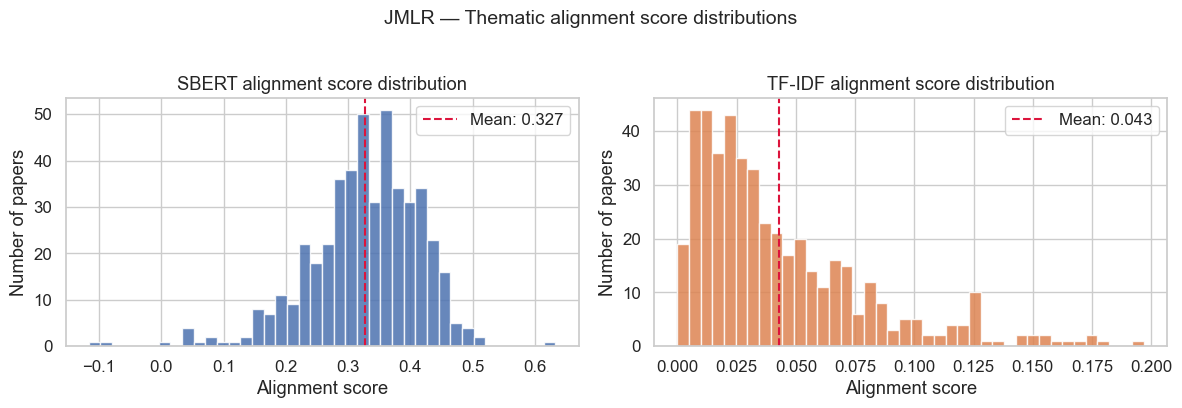

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color, label in [
    (axes[0], SBERT_COL,  "#4C72B0", "SBERT"),
    (axes[1], TFIDF_COL, "#DD8452", "TF-IDF"),
]:
    ax.hist(df[col], bins=40, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(df[col].mean(), color="crimson", linestyle="--", linewidth=1.5,
               label=f"Mean: {df[col].mean():.3f}")
    ax.set_title(f"{label} alignment score distribution")
    ax.set_xlabel("Alignment score")
    ax.set_ylabel("Number of papers")
    ax.legend()

fig.suptitle("JMLR — Thematic alignment score distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 9b. Temporal drift

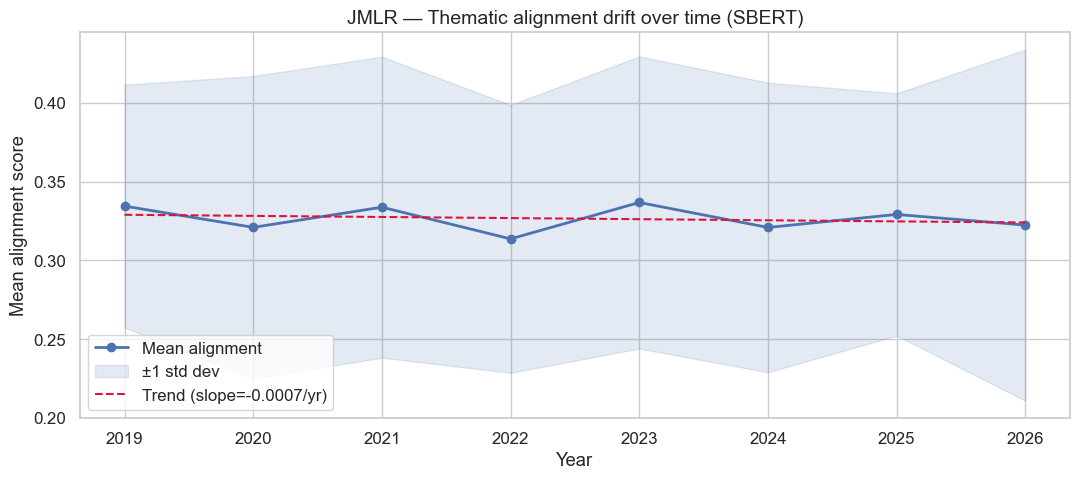

In [23]:
yearly = (
    df.groupby("year")[SBERT_COL]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "avg_score", "std": "std_score", "count": "n_papers"})
)
yearly = yearly[yearly["n_papers"] >= 3]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly["year"], yearly["avg_score"], marker="o", linewidth=2,
        color="#4C72B0", label="Mean alignment")
ax.fill_between(
    yearly["year"],
    yearly["avg_score"] - yearly["std_score"],
    yearly["avg_score"] + yearly["std_score"],
    alpha=0.15, color="#4C72B0", label="±1 std dev",
)

z = np.polyfit(yearly["year"], yearly["avg_score"], 1)
trend = np.poly1d(z)
ax.plot(yearly["year"], trend(yearly["year"]), linestyle="--", color="crimson",
        linewidth=1.5, label=f"Trend (slope={z[0]:+.4f}/yr)")

ax.set_title("JMLR — Thematic alignment drift over time (SBERT)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Mean alignment score")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

### 9c. Top / bottom papers bar chart

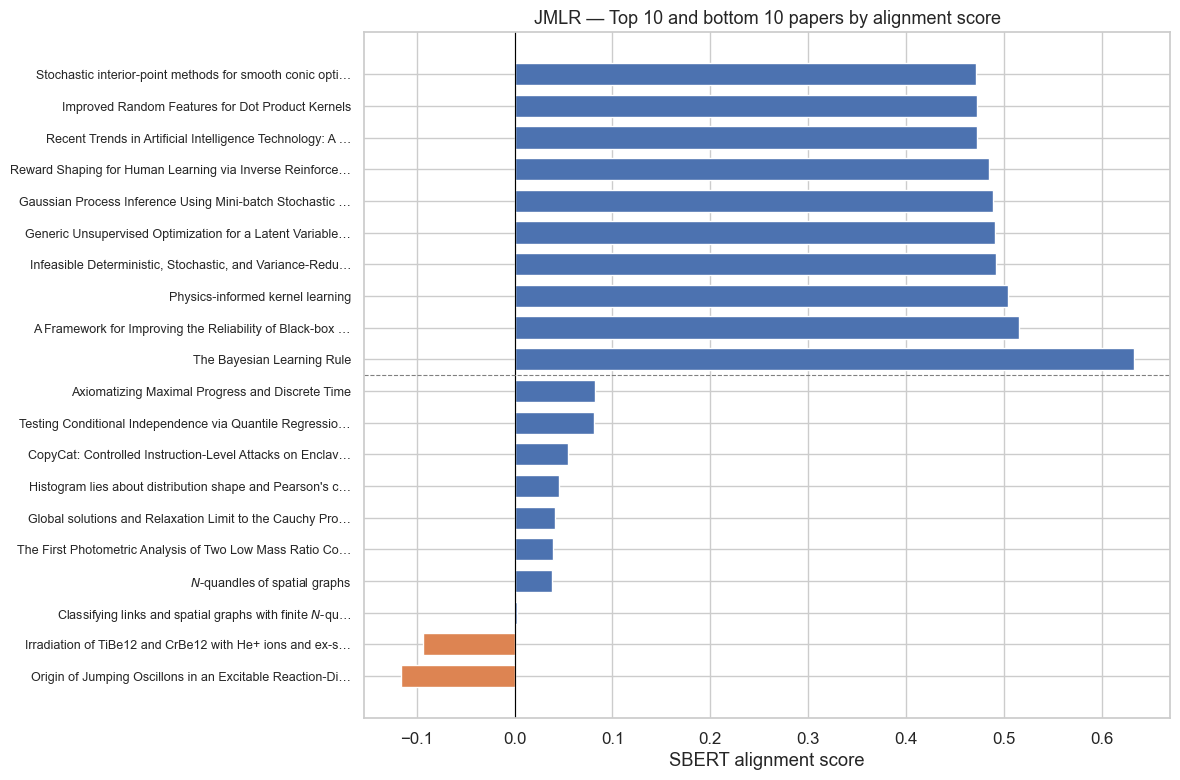

In [24]:
n = 10
top    = df.nlargest(n, SBERT_COL)
bottom = df.nsmallest(n, SBERT_COL)
combined = pd.concat([bottom, top])

labels = [t[:55] + "…" if len(t) > 55 else t for t in combined["title"]]
scores = combined[SBERT_COL].values
colors = ["#DD8452" if s < 0 else "#4C72B0" for s in scores]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(scores)), scores, color=colors, edgecolor="white", height=0.7)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.axhline(n - 0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("SBERT alignment score")
ax.set_title(f"JMLR — Top {n} and bottom {n} papers by alignment score", fontsize=13)
plt.tight_layout()
plt.show()

### 9d. Outlier distribution with ±2σ bands

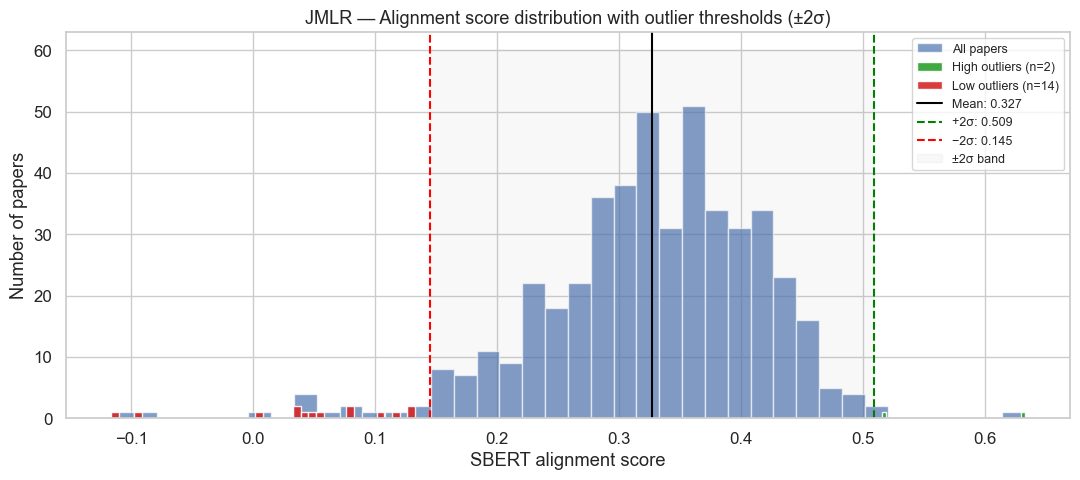

In [25]:
upper = mean + 2 * std
lower = mean - 2 * std

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df[SBERT_COL], bins=40, color="#4C72B0", alpha=0.7,
        edgecolor="white", label="All papers")

high_mask = df["outlier_type"] == "high"
low_mask  = df["outlier_type"] == "low"

if high_mask.any():
    ax.hist(df.loc[high_mask, SBERT_COL], bins=40, color="#2ca02c", alpha=0.9,
            edgecolor="white", label=f"High outliers (n={high_mask.sum()})")
if low_mask.any():
    ax.hist(df.loc[low_mask, SBERT_COL], bins=40, color="#d62728", alpha=0.9,
            edgecolor="white", label=f"Low outliers (n={low_mask.sum()})")

ax.axvline(mean,  color="black", linestyle="-",  linewidth=1.5, label=f"Mean: {mean:.3f}")
ax.axvline(upper, color="green", linestyle="--", linewidth=1.5, label=f"+2σ: {upper:.3f}")
ax.axvline(lower, color="red",   linestyle="--", linewidth=1.5, label=f"−2σ: {lower:.3f}")
ax.fill_betweenx([0, 60], lower, upper, alpha=0.05, color="gray", label="±2σ band")

ax.set_xlabel("SBERT alignment score")
ax.set_ylabel("Number of papers")
ax.set_title("JMLR — Alignment score distribution with outlier thresholds (±2σ)", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 9e. Topic distribution (papers per topic, coloured by alignment)

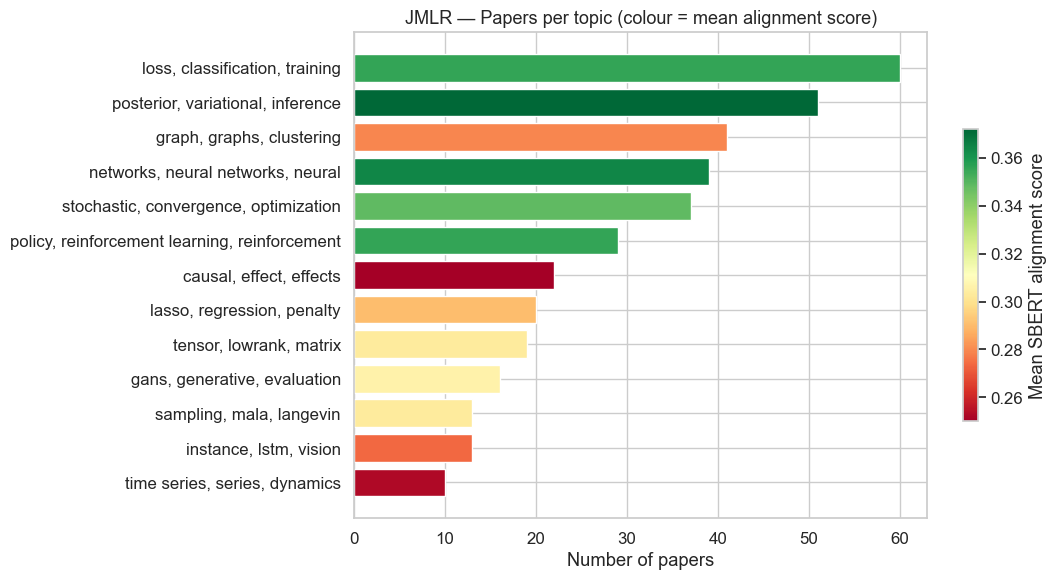

In [26]:
topic_counts = (
    df[df["topic_id"] != -1]
    .groupby("topic_label")
    .agg(n_papers=("title", "count"), mean_alignment=(SBERT_COL, "mean"))
    .reset_index()
    .sort_values("n_papers", ascending=True)
)

norm_colors = plt.cm.RdYlGn(
    (topic_counts["mean_alignment"] - topic_counts["mean_alignment"].min()) /
    (topic_counts["mean_alignment"].max() - topic_counts["mean_alignment"].min())
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(topic_counts["topic_label"], topic_counts["n_papers"],
        color=norm_colors, edgecolor="white")
ax.set_xlabel("Number of papers")
ax.set_title("JMLR — Papers per topic (colour = mean alignment score)", fontsize=13)

sm = plt.cm.ScalarMappable(
    cmap="RdYlGn",
    norm=plt.Normalize(topic_counts["mean_alignment"].min(),
                       topic_counts["mean_alignment"].max()),
)
plt.colorbar(sm, ax=ax, label="Mean SBERT alignment score", shrink=0.6)
plt.tight_layout()
plt.show()

### 9f. Topic drift over time (top 6 topics)

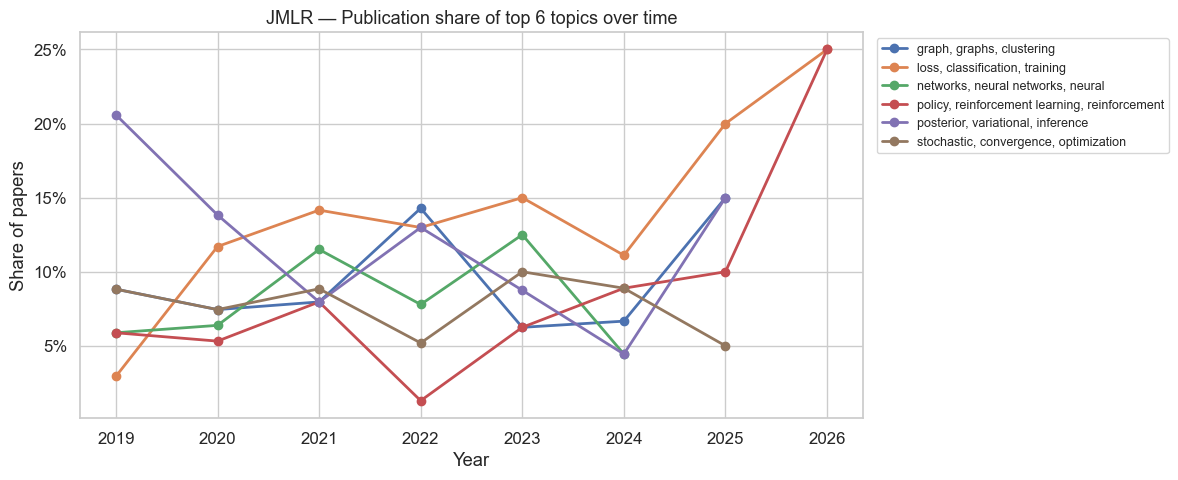

In [27]:
TOP_N = 6
top_topics = (
    df[df["topic_id"] != -1]
    .groupby("topic_label")["title"]
    .count()
    .nlargest(TOP_N)
    .index.tolist()
)

yearly_topics = (
    df[df["topic_label"].isin(top_topics)]
    .groupby(["year", "topic_label"])["title"]
    .count()
    .reset_index(name="count")
)
yearly_totals = df.groupby("year")["title"].count().reset_index(name="total")
yearly_topics = yearly_topics.merge(yearly_totals, on="year")
yearly_topics["share"] = yearly_topics["count"] / yearly_topics["total"]

fig, ax = plt.subplots(figsize=(12, 5))
for topic, group in yearly_topics.groupby("topic_label"):
    ax.plot(group["year"], group["share"], marker="o", linewidth=2, label=topic)

ax.set_title(f"JMLR — Publication share of top {TOP_N} topics over time", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Share of papers")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### 9g. Topic × Year alignment heatmap

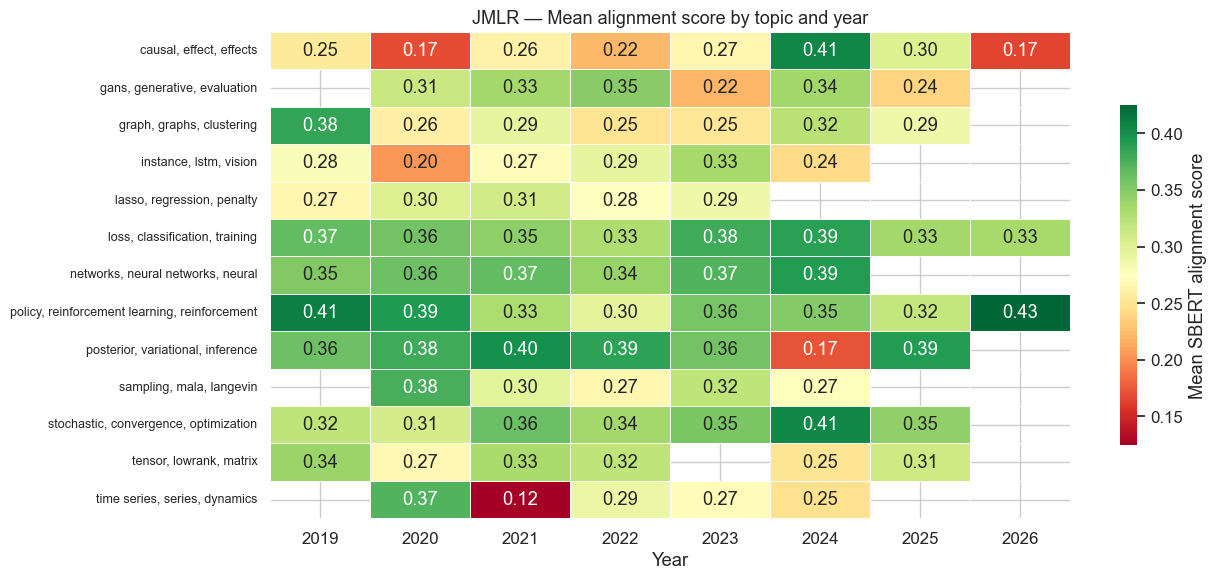

In [28]:
pivot = (
    df[df["topic_id"] != -1]
    .groupby(["topic_label", "year"])[SBERT_COL]
    .mean()
    .unstack(level="year")
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot, ax=ax, cmap="RdYlGn",
    annot=True, fmt=".2f",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Mean SBERT alignment score", "shrink": 0.7},
)
ax.set_title("JMLR — Mean alignment score by topic and year", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

### 9h. UMAP — by topic

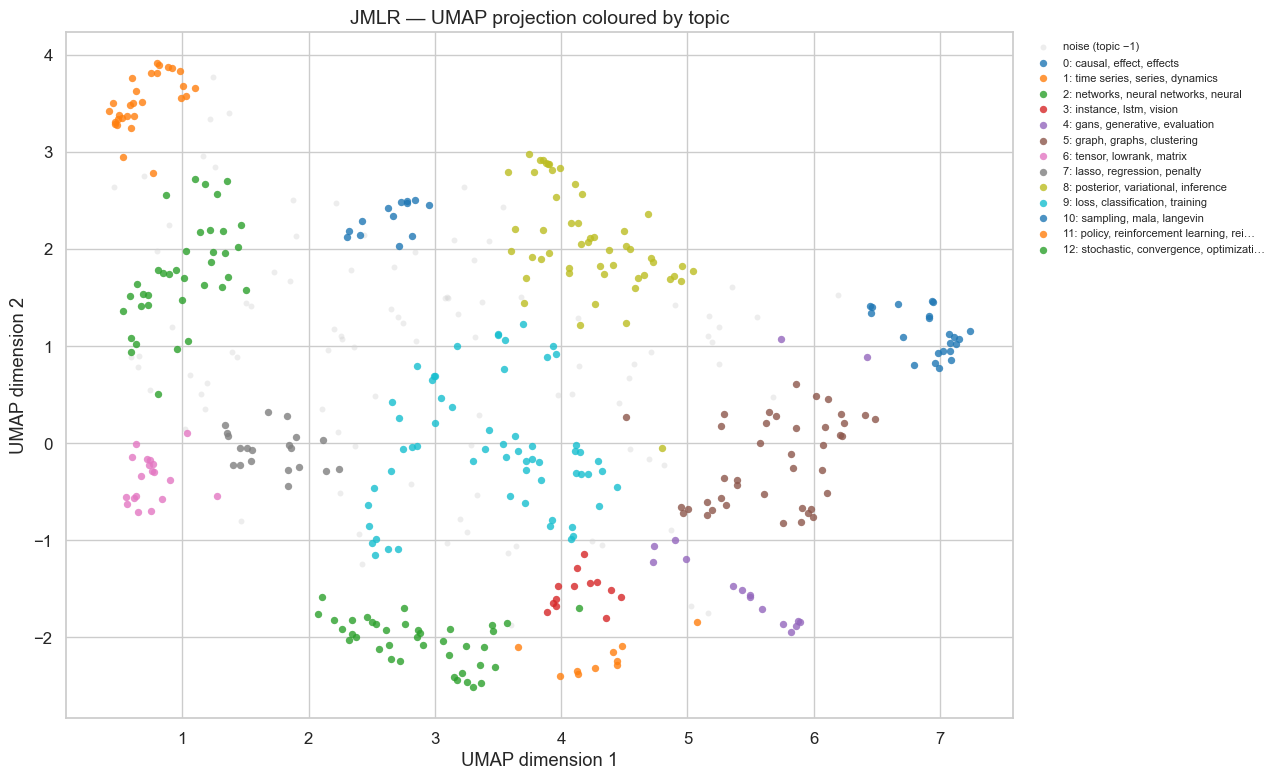

In [29]:
fig, ax = plt.subplots(figsize=(13, 8))

noise = df[df["topic_id"] == -1]
ax.scatter(noise["umap_x"], noise["umap_y"],
           c="lightgrey", s=18, alpha=0.4, linewidths=0, label="noise (topic −1)")

non_noise = df[df["topic_id"] != -1]
palette   = sns.color_palette("tab10", n_colors=non_noise["topic_id"].nunique())
for i, (tid, group) in enumerate(non_noise.groupby("topic_id")):
    lbl   = group["topic_label"].iloc[0]
    short = lbl[:35] + "…" if len(lbl) > 35 else lbl
    ax.scatter(group["umap_x"], group["umap_y"],
               color=palette[i], s=28, alpha=0.8, linewidths=0,
               label=f"{tid}: {short}")

ax.set_title("JMLR — UMAP projection coloured by topic", fontsize=14)
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

### 9i. UMAP — by alignment score

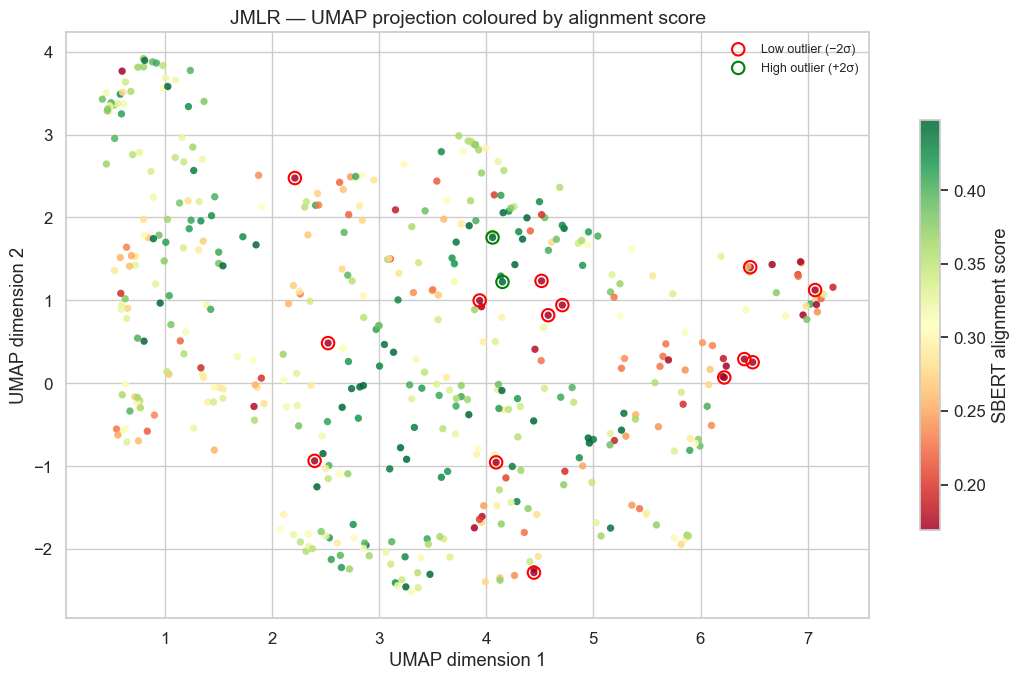

In [30]:
fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(
    df["umap_x"], df["umap_y"],
    c=df[SBERT_COL], cmap="RdYlGn",
    s=28, alpha=0.85, linewidths=0,
    vmin=df[SBERT_COL].quantile(0.05),
    vmax=df[SBERT_COL].quantile(0.95),
)

low_out  = df[df["outlier_type"] == "low"]
high_out = df[df["outlier_type"] == "high"]

if not low_out.empty:
    ax.scatter(low_out["umap_x"], low_out["umap_y"],
               edgecolors="red", facecolors="none",
               s=80, linewidths=1.5, label="Low outlier (−2σ)")
if not high_out.empty:
    ax.scatter(high_out["umap_x"], high_out["umap_y"],
               edgecolors="green", facecolors="none",
               s=80, linewidths=1.5, label="High outlier (+2σ)")

plt.colorbar(sc, ax=ax, label="SBERT alignment score", shrink=0.7)
ax.set_title("JMLR — UMAP projection coloured by alignment score", fontsize=14)
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

### 9j. UMAP — by publication year

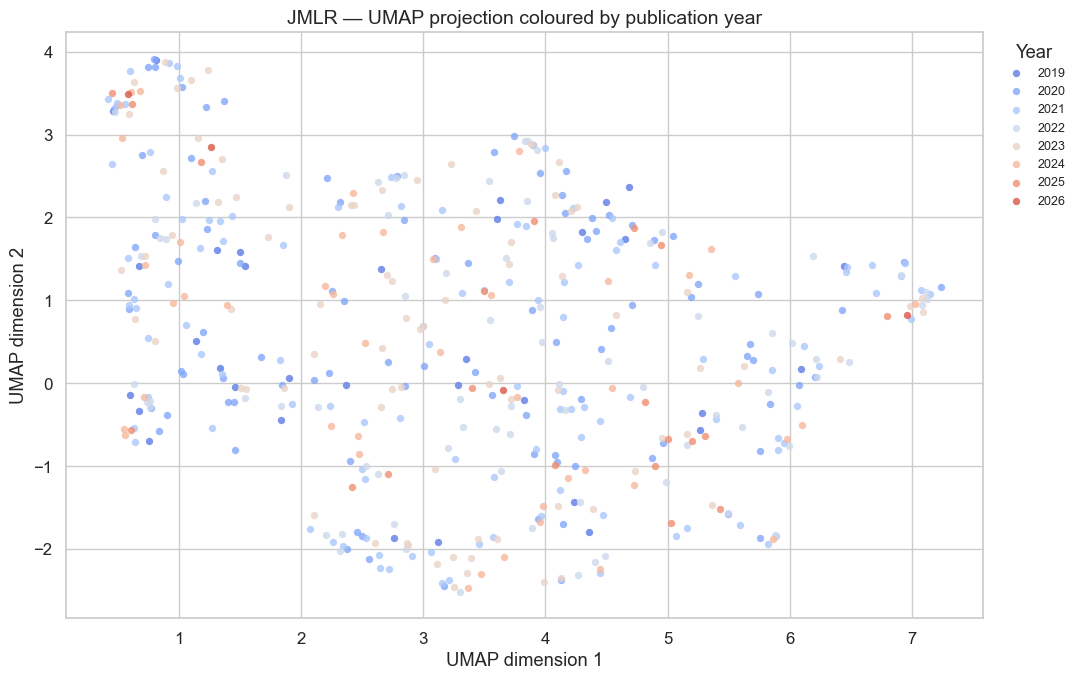

In [31]:
years      = sorted(df["year"].unique())
year_pal   = sns.color_palette("coolwarm", n_colors=len(years))
year_color = {y: year_pal[i] for i, y in enumerate(years)}

fig, ax = plt.subplots(figsize=(11, 7))
for year, group in df.groupby("year"):
    ax.scatter(group["umap_x"], group["umap_y"],
               color=year_color[year], s=28,
               alpha=0.8, linewidths=0, label=str(year))

ax.set_title("JMLR — UMAP projection coloured by publication year", fontsize=14)
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.legend(title="Year", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

## 10. Key Findings

| Metric | Value |
|--------|-------|
| SBERT mean alignment score | ~0.327 |
| Temporal drift slope | −0.0007 / year |
| High outliers (>+2σ) | 2 papers |
| Low outliers (<−2σ) | 14 papers |

**Thematic drift:** A negative slope of −0.0007/year indicates JMLR has gradually broadened beyond its classical statistical learning scope, driven by the large neural-networks topic cluster.

**Outliers:** The 14 low-scoring papers (physics, materials science, pure mathematics) are almost certainly arXiv cross-listing artifacts, not papers genuinely published in JMLR.

**Topic alignment:** loss/variational topics score highest (≈0.39) because the Aims & Scope text directly mentions probabilistic approaches. Graph and time series topics score lower despite being legitimate JMLR content — a known limitation of scope-text cosine similarity.

## 11. Examples of High Outlier & Low Outlier

In [32]:
highest_outlier = df[df["outlier_type"] == "high"].nlargest(1, SBERT_COL)
lowest_outlier = df[df["outlier_type"] == "low"].nsmallest(1, SBERT_COL)

print("=== HIGHEST OUTLIER ABSTRACT ===\n")
print(highest_outlier["abstract"].iloc[0])
print("\n\n=== LOWEST OUTLIER ABSTRACT ===\n")
print(lowest_outlier["abstract"].iloc[0])

=== HIGHEST OUTLIER ABSTRACT ===

We show that many machine-learning algorithms are specific instances of a single algorithm called the \emph{Bayesian learning rule}. The rule, derived from Bayesian principles, yields a wide-range of algorithms from fields such as optimization, deep learning, and graphical models. This includes classical algorithms such as ridge regression, Newton's method, and Kalman filter, as well as modern deep-learning algorithms such as stochastic-gradient descent, RMSprop, and Dropout. The key idea in deriving such algorithms is to approximate the posterior using candidate distributions estimated by using natural gradients. Different candidate distributions result in different algorithms and further approximations to natural gradients give rise to variants of those algorithms. Our work not only unifies, generalizes, and improves existing algorithms, but also helps us design new ones.


=== LOWEST OUTLIER ABSTRACT ===

Oscillons, i.e., immobile spatially localize